In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Set working directory
os.chdir(r"C:\Users\srira\OneDrive\Desktop\bluestock_project")

# Load all required files
nav_df = pd.read_csv("data/processed/nav_history_clean.csv")
benchmark_df = pd.read_csv("data/processed/benchmark_indices_clean.csv")
fund_master_df = pd.read_csv("data/processed/fund_master_clean.csv")

# Convert dates
nav_df['date'] = pd.to_datetime(nav_df['date'])
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

print("All libraries imported and files loaded! ")
print("NAV shape:", nav_df.shape)
print("Benchmark shape:", benchmark_df.shape)
print("Fund Master shape:", fund_master_df.shape)

All libraries imported and files loaded! 
NAV shape: (64320, 6)
Benchmark shape: (8050, 3)
Fund Master shape: (40, 15)


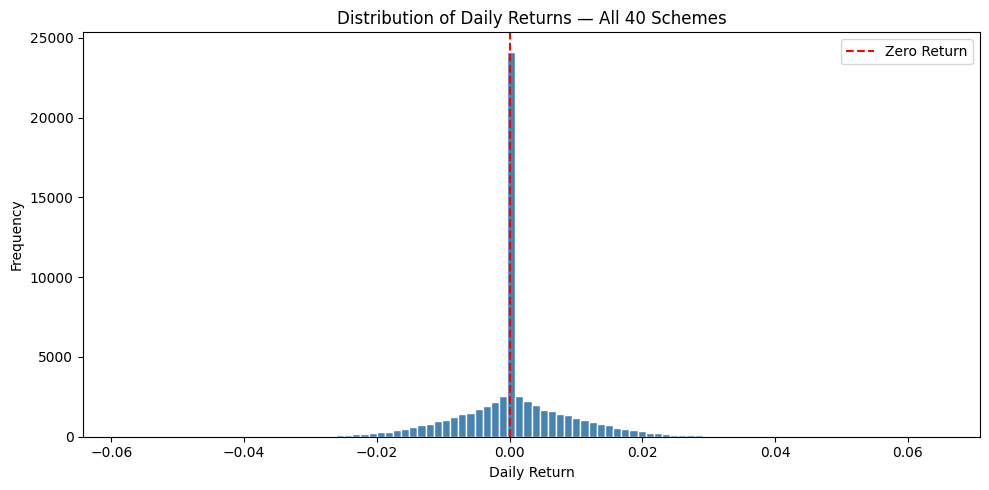

Daily Returns computed! 
    amfi_code       date       nav  daily_return
1      100016 2022-01-04  515.0971     -0.010306
2      100016 2022-01-05  521.7239      0.012865
3      100016 2022-01-06  515.7880     -0.011377
4      100016 2022-01-07  515.1639     -0.001210
5      100016 2022-01-08  515.1639      0.000000
6      100016 2022-01-09  515.1639      0.000000
7      100016 2022-01-10  510.7136     -0.008639
8      100016 2022-01-11  513.5542      0.005562
9      100016 2022-01-12  512.3195     -0.002404
10     100016 2022-01-13  510.2445     -0.004050


In [3]:
# TASK 1 - Compute Daily Returns for all 40 schemes

# Sort by fund and date
nav_df = nav_df.sort_values(['amfi_code', 'date'])

# Compute daily return = nav_t / nav_t-1 - 1
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()

# Drop NaN rows
returns_df = nav_df.dropna(subset=['daily_return'])

# Validate distribution
plt.figure(figsize=(10, 5))
plt.hist(returns_df['daily_return'], bins=100, color='steelblue', edgecolor='white')
plt.title('Distribution of Daily Returns — All 40 Schemes')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.axvline(x=0, color='red', linestyle='--', label='Zero Return')
plt.legend()
plt.tight_layout()
plt.savefig("reports/task1_daily_returns_dist.png")
plt.show()

print("Daily Returns computed! ")
print(returns_df[['amfi_code', 'date', 'nav', 'daily_return']].head(10))

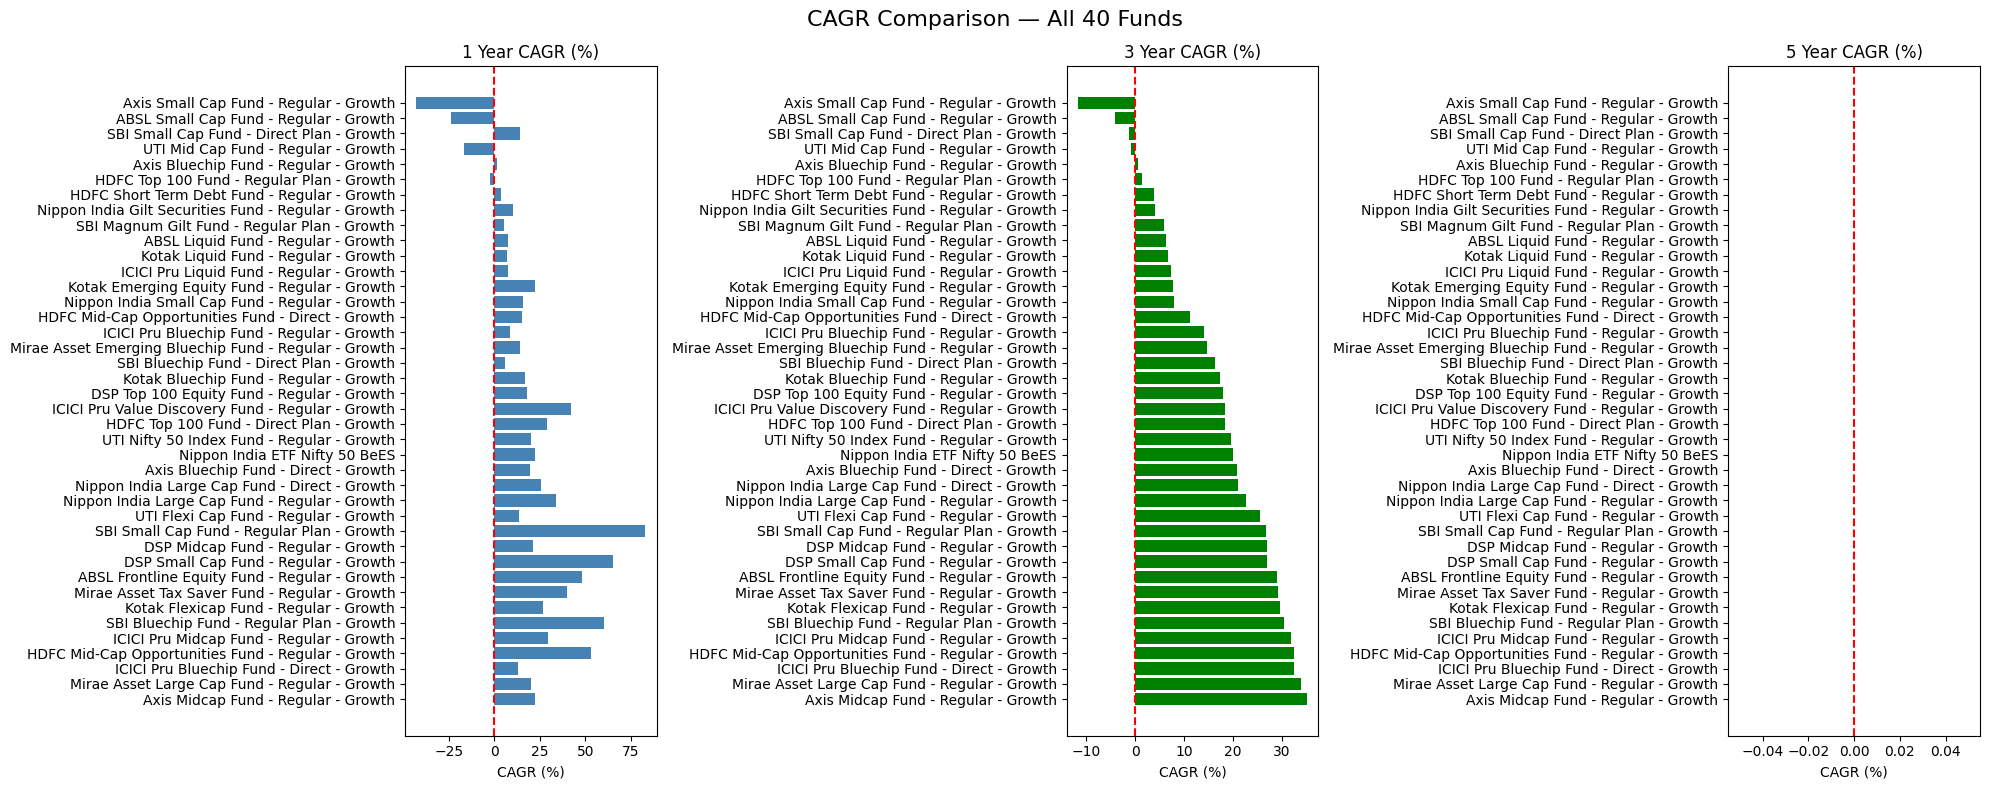

Task 2 CAGR Done! 


In [12]:
# TASK 2 - CAGR Computation + Visualization (Fixed)

def compute_cagr(nav_series, years):
    try:
        end_date = nav_series.index.max()
        start_date = end_date - pd.DateOffset(years=years)
        nav_end = nav_series[nav_series.index >= end_date].iloc[-1]
        nav_start = nav_series[nav_series.index <= start_date].iloc[-1]
        cagr = (nav_end / nav_start) ** (1 / years) - 1
        return round(cagr * 100, 2)
    except:
        return 0.0

# Pivot NAV data
nav_pivot = nav_df.pivot_table(index='date', columns='amfi_code', values='nav')

# Compute CAGR for each fund
cagr_results = []
for fund in nav_pivot.columns:
    series = nav_pivot[fund].dropna()
    cagr_results.append({
        'amfi_code': fund,
        'CAGR_1yr': compute_cagr(series, 1),
        'CAGR_3yr': compute_cagr(series, 3),
        'CAGR_5yr': compute_cagr(series, 5)
    })

cagr_df = pd.DataFrame(cagr_results)
cagr_df = cagr_df.merge(fund_master_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
cagr_df = cagr_df.sort_values('CAGR_3yr', ascending=False).reset_index(drop=True)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# 1yr CAGR
axes[0].barh(cagr_df['scheme_name'], cagr_df['CAGR_1yr'], color='steelblue')
axes[0].set_title('1 Year CAGR (%)')
axes[0].set_xlabel('CAGR (%)')
axes[0].axvline(x=0, color='red', linestyle='--')

# 3yr CAGR
axes[1].barh(cagr_df['scheme_name'], cagr_df['CAGR_3yr'], color='green')
axes[1].set_title('3 Year CAGR (%)')
axes[1].set_xlabel('CAGR (%)')
axes[1].axvline(x=0, color='red', linestyle='--')

# 5yr CAGR
axes[2].barh(cagr_df['scheme_name'], cagr_df['CAGR_5yr'], color='orange')
axes[2].set_title('5 Year CAGR (%)')
axes[2].set_xlabel('CAGR (%)')
axes[2].axvline(x=0, color='red', linestyle='--')

plt.suptitle('CAGR Comparison — All 40 Funds', fontsize=16)
plt.tight_layout()
plt.savefig("reports/task2_cagr.png")
plt.show()
print("Task 2 CAGR Done! ")

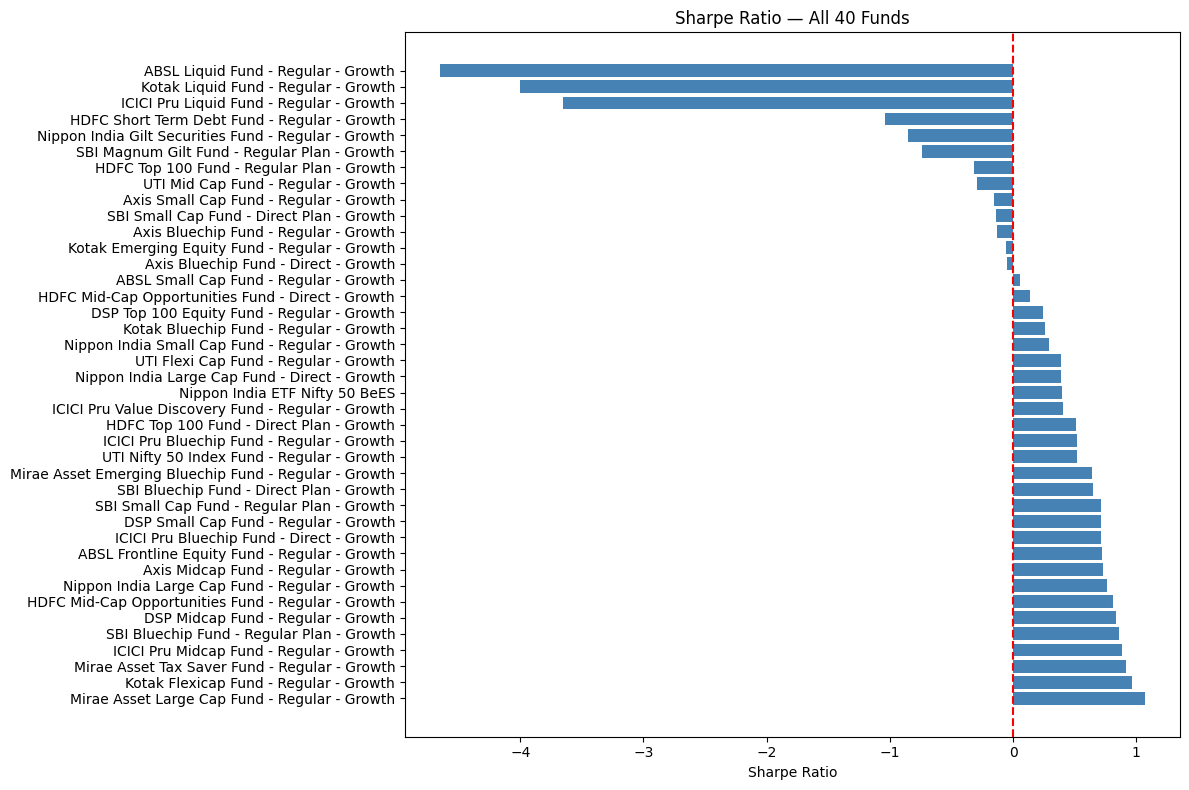

Task 3 Sharpe Done! 


In [14]:
# TASK 3 - Sharpe Ratio + Visualization

rf_daily = 0.065 / 252

sharpe_results = []
for fund in returns_df['amfi_code'].unique():
    fund_returns = returns_df[returns_df['amfi_code'] == fund]['daily_return']
    excess_returns = fund_returns - rf_daily
    sharpe = (excess_returns.mean() / fund_returns.std()) * np.sqrt(252)
    sharpe_results.append({
        'amfi_code': fund,
        'sharpe_ratio': round(sharpe, 4)
    })

sharpe_df = pd.DataFrame(sharpe_results)
sharpe_df = sharpe_df.merge(fund_master_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
sharpe_df = sharpe_df.sort_values('sharpe_ratio', ascending=False).reset_index(drop=True)
sharpe_df['sharpe_rank'] = sharpe_df['sharpe_ratio'].rank(ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(sharpe_df['scheme_name'], sharpe_df['sharpe_ratio'], color='steelblue')
plt.title('Sharpe Ratio — All 40 Funds')
plt.xlabel('Sharpe Ratio')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.savefig("reports/task3_sharpe.png")
plt.show()
print("Task 3 Sharpe Done! ")

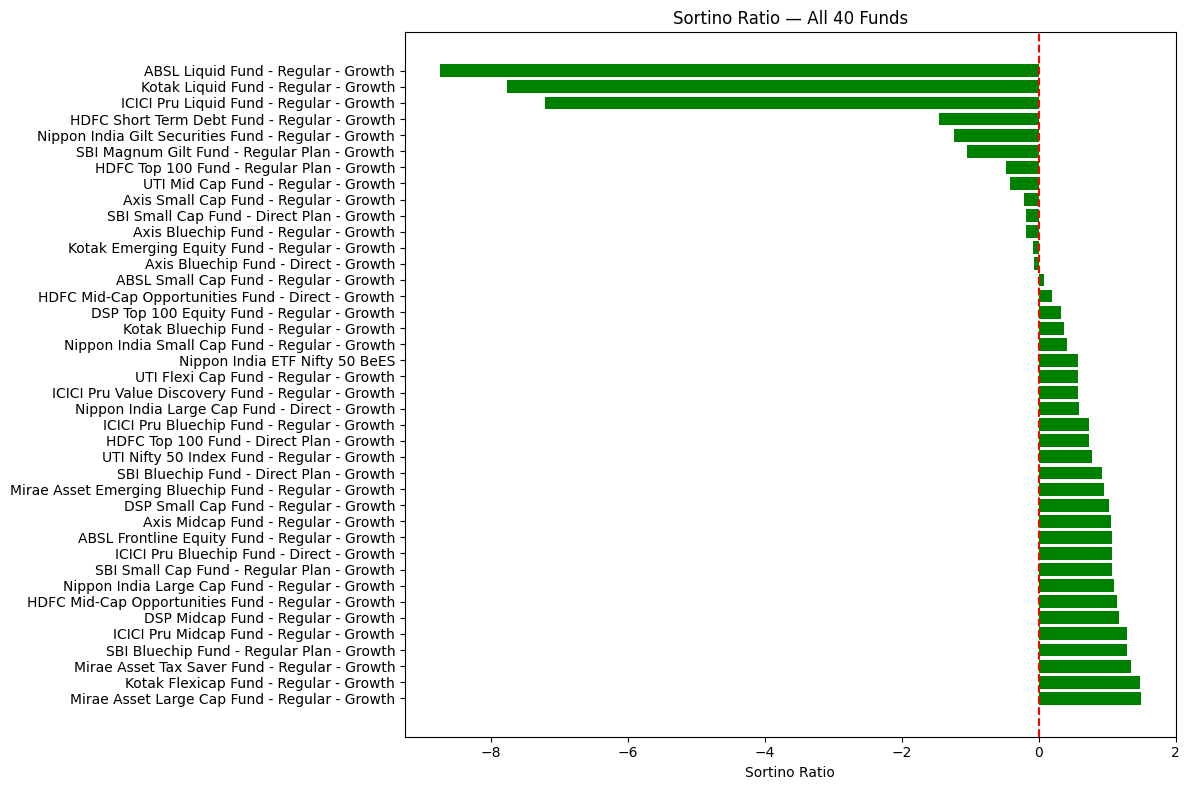

Task 4 Sortino Done! 


In [15]:
# TASK 4 - Sortino Ratio + Visualization

rf_daily = 0.065 / 252

sortino_results = []
for fund in returns_df['amfi_code'].unique():
    fund_returns = returns_df[returns_df['amfi_code'] == fund]['daily_return']
    excess_returns = fund_returns - rf_daily
    downside_returns = fund_returns[fund_returns < 0]
    downside_std = downside_returns.std()
    sortino = (excess_returns.mean() / downside_std) * np.sqrt(252)
    sortino_results.append({
        'amfi_code': fund,
        'sortino_ratio': round(sortino, 4)
    })

sortino_df = pd.DataFrame(sortino_results)
sortino_df = sortino_df.merge(fund_master_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
sortino_df = sortino_df.sort_values('sortino_ratio', ascending=False).reset_index(drop=True)
sortino_df['sortino_rank'] = sortino_df['sortino_ratio'].rank(ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(sortino_df['scheme_name'], sortino_df['sortino_ratio'], color='green')
plt.title('Sortino Ratio — All 40 Funds')
plt.xlabel('Sortino Ratio')
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.savefig("reports/task4_sortino.png")
plt.show()
print("Task 4 Sortino Done! ")

In [9]:
print(benchmark_df.columns.tolist())
print(benchmark_df.head())

['date', 'index_name', 'close_value']
        date index_name  close_value
0 2022-01-03    NIFTY50     17492.79
1 2022-01-04    NIFTY50     17689.64
2 2022-01-05    NIFTY50     17835.05
3 2022-01-06    NIFTY50     17878.51
4 2022-01-07    NIFTY50     17759.15


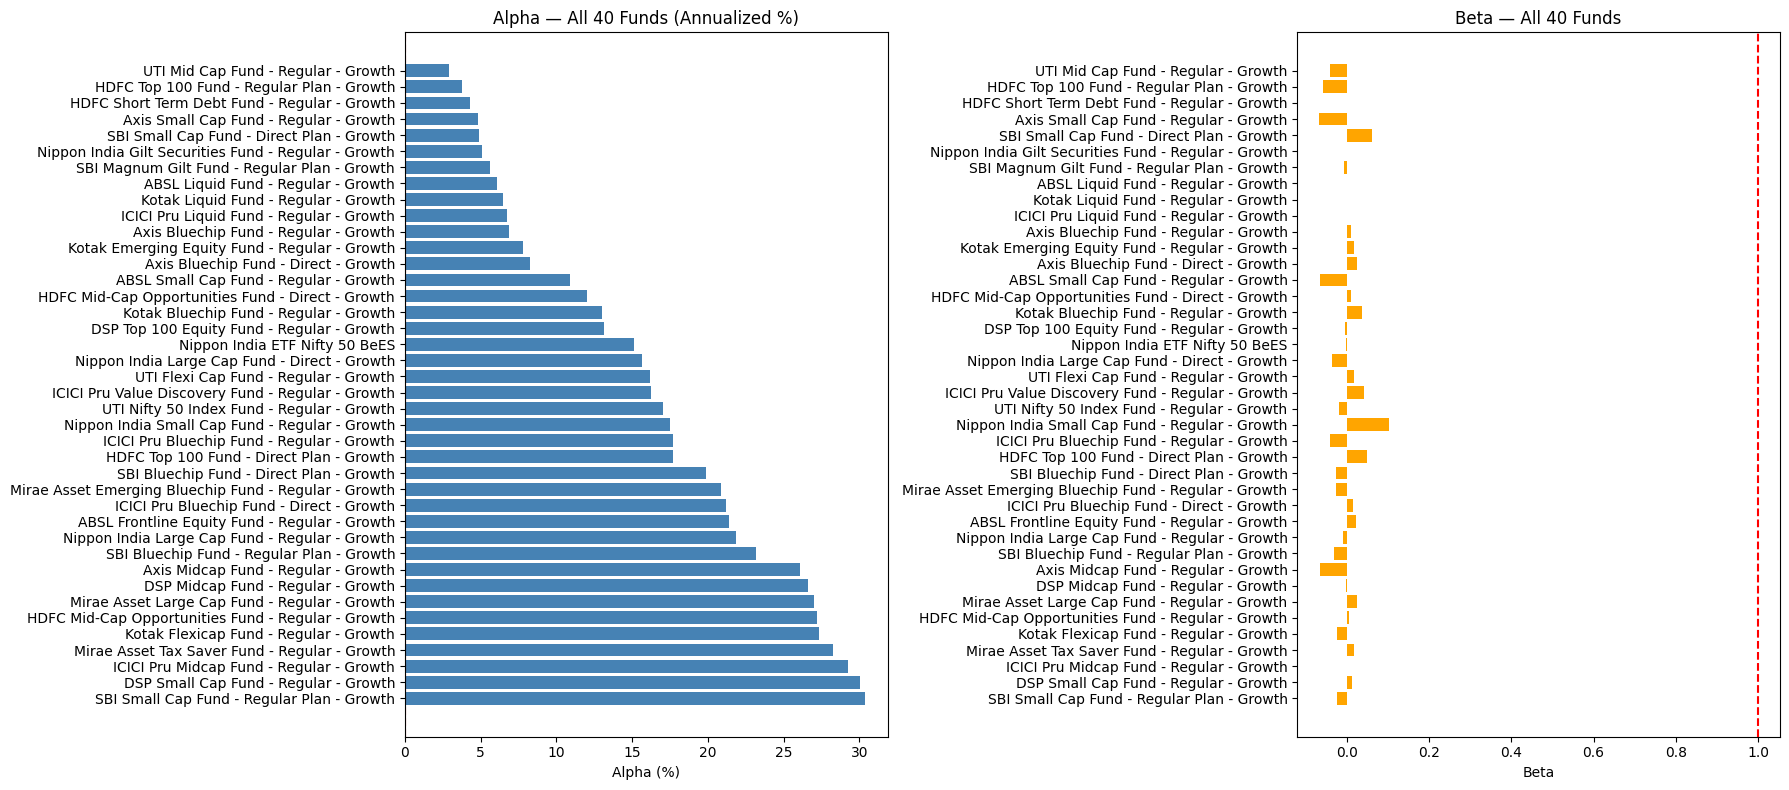

Task 5 Alpha & Beta Done! 


In [17]:
# TASK 5 - Alpha & Beta + Visualization

nifty100 = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date')
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna()

alpha_beta_results = []
for fund in returns_df['amfi_code'].unique():
    fund_returns = returns_df[returns_df['amfi_code'] == fund][['date', 'daily_return']]
    merged = fund_returns.merge(nifty100[['date', 'benchmark_return']], on='date', how='inner')
    if len(merged) < 30:
        continue
    slope, intercept, r_value, p_value, std_err = stats.linregress(
        merged['benchmark_return'], merged['daily_return']
    )
    alpha_beta_results.append({
        'amfi_code': fund,
        'beta': round(slope, 4),
        'alpha': round(intercept * 252 * 100, 4),
        'r_squared': round(r_value**2, 4)
    })

alpha_beta_df = pd.DataFrame(alpha_beta_results)
alpha_beta_df = alpha_beta_df.merge(fund_master_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
alpha_beta_df = alpha_beta_df.sort_values('alpha', ascending=False).reset_index(drop=True)
alpha_beta_df['alpha_rank'] = alpha_beta_df['alpha'].rank(ascending=False)
alpha_beta_df.to_csv("reports/alpha_beta.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
axes[0].barh(alpha_beta_df['scheme_name'], alpha_beta_df['alpha'], color='steelblue')
axes[0].set_title('Alpha — All 40 Funds (Annualized %)')
axes[0].set_xlabel('Alpha (%)')
axes[0].axvline(x=0, color='red', linestyle='--')

axes[1].barh(alpha_beta_df['scheme_name'], alpha_beta_df['beta'], color='orange')
axes[1].set_title('Beta — All 40 Funds')
axes[1].set_xlabel('Beta')
axes[1].axvline(x=1, color='red', linestyle='--')

plt.tight_layout()
plt.savefig("reports/task5_alpha_beta.png")
plt.show()
print("Task 5 Alpha & Beta Done! ")

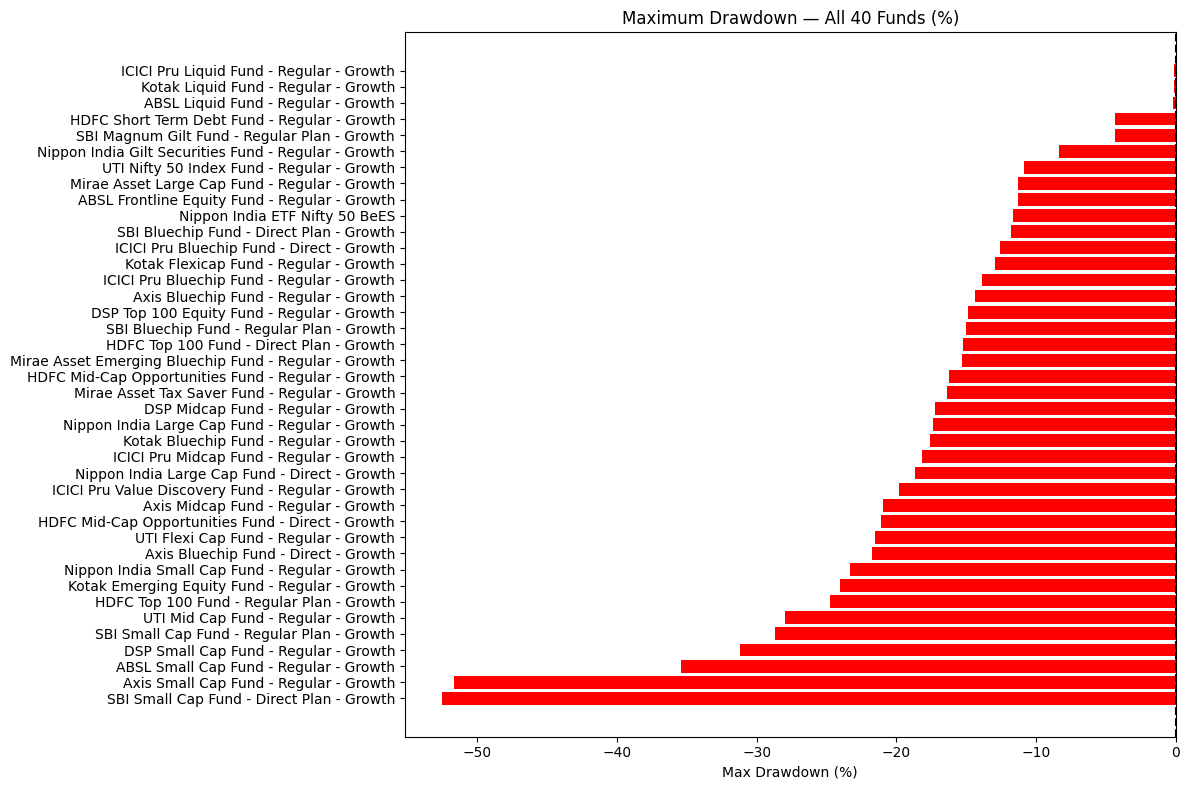

Task 6 Max Drawdown Done! 


In [18]:
# TASK 6 - Maximum Drawdown + Visualization

drawdown_results = []
for fund in nav_pivot.columns:
    series = nav_pivot[fund].dropna()
    rolling_max = series.cummax()
    drawdown = (series / rolling_max) - 1
    max_dd = drawdown.min()
    max_dd_date = drawdown.idxmin()
    drawdown_results.append({
        'amfi_code': fund,
        'max_drawdown': round(max_dd * 100, 2),
        'worst_date': max_dd_date
    })

drawdown_df = pd.DataFrame(drawdown_results)
drawdown_df = drawdown_df.merge(fund_master_df[['amfi_code', 'scheme_name']], on='amfi_code', how='left')
drawdown_df = drawdown_df.sort_values('max_drawdown', ascending=True).reset_index(drop=True)
drawdown_df['dd_rank'] = drawdown_df['max_drawdown'].rank(ascending=False)

plt.figure(figsize=(12, 8))
plt.barh(drawdown_df['scheme_name'], drawdown_df['max_drawdown'], color='red')
plt.title('Maximum Drawdown — All 40 Funds (%)')
plt.xlabel('Max Drawdown (%)')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig("reports/task6_max_drawdown.png")
plt.show()
print("Task 6 Max Drawdown Done! ")

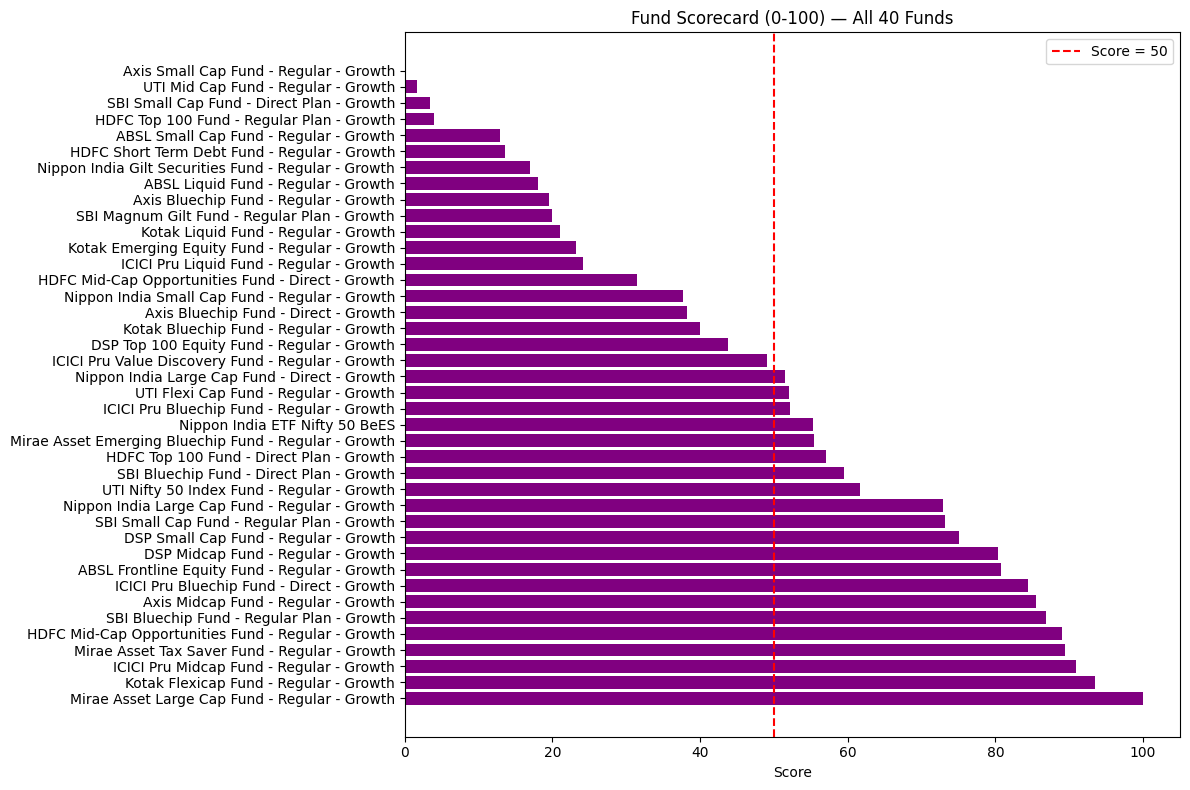

Task 7 Fund Scorecard Done! 


In [19]:
# TASK 7 - Fund Scorecard (0-100)

scorecard_df = cagr_df[['amfi_code', 'scheme_name', 'CAGR_3yr']].copy()
scorecard_df['cagr_rank'] = scorecard_df['CAGR_3yr'].rank(ascending=False)

scorecard_df = scorecard_df.merge(sharpe_df[['amfi_code', 'sharpe_rank']], on='amfi_code', how='left')
scorecard_df = scorecard_df.merge(alpha_beta_df[['amfi_code', 'alpha_rank']], on='amfi_code', how='left')
scorecard_df = scorecard_df.merge(drawdown_df[['amfi_code', 'dd_rank']], on='amfi_code', how='left')

# Add expense ratio rank from fund master
if 'expense_ratio' in fund_master_df.columns:
    exp_df = fund_master_df[['amfi_code', 'expense_ratio']].copy()
    exp_df['expense_rank'] = exp_df['expense_ratio'].rank(ascending=True)
    scorecard_df = scorecard_df.merge(exp_df[['amfi_code', 'expense_rank']], on='amfi_code', how='left')
else:
    scorecard_df['expense_rank'] = 20

n = len(scorecard_df)

# Composite Score
scorecard_df['score'] = (
    0.30 * (n - scorecard_df['cagr_rank']) +
    0.25 * (n - scorecard_df['sharpe_rank']) +
    0.20 * (n - scorecard_df['alpha_rank']) +
    0.15 * (n - scorecard_df['expense_rank']) +
    0.10 * (n - scorecard_df['dd_rank'])
)

# Normalize to 0-100
scorecard_df['score'] = round(
    (scorecard_df['score'] - scorecard_df['score'].min()) /
    (scorecard_df['score'].max() - scorecard_df['score'].min()) * 100, 2
)

scorecard_df = scorecard_df.sort_values('score', ascending=False).reset_index(drop=True)
scorecard_df.to_csv("reports/fund_scorecard.csv", index=False)

plt.figure(figsize=(12, 8))
plt.barh(scorecard_df['scheme_name'], scorecard_df['score'], color='purple')
plt.title('Fund Scorecard (0-100) — All 40 Funds')
plt.xlabel('Score')
plt.axvline(x=50, color='red', linestyle='--', label='Score = 50')
plt.legend()
plt.tight_layout()
plt.savefig("reports/task7_fund_scorecard.png")
plt.show()
print("Task 7 Fund Scorecard Done! ")

In [21]:
# TASK 8 - 

# Get top 5 funds by scorecard
top5_funds = scorecard_df.head(5)['amfi_code'].tolist()
top5_names = scorecard_df.head(5)['scheme_name'].tolist()

# Get Nifty 50 and Nifty 100 fresh
nifty50 = benchmark_df[benchmark_df['index_name'] == 'NIFTY50'].copy()
nifty50 = nifty50.sort_values('date').reset_index(drop=True)
nifty50['benchmark_return'] = nifty50['close_value'].pct_change()
nifty50 = nifty50.dropna()

nifty100 = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].copy()
nifty100 = nifty100.sort_values('date').reset_index(drop=True)
nifty100['benchmark_return'] = nifty100['close_value'].pct_change()
nifty100 = nifty100.dropna()

# Filter last 3 years
start_3yr = pd.Timestamp('2023-01-01')

fig = go.Figure()

# Plot top 5 funds normalized to 100
for fund, name in zip(top5_funds, top5_names):
    series = nav_pivot[fund].dropna()
    series = series[series.index >= start_3yr]
    normalized = (series / series.iloc[0]) * 100
    fig.add_trace(go.Scatter(x=normalized.index, y=normalized.values, name=name, mode='lines'))

# Plot Nifty 50
n50 = nifty50[nifty50['date'] >= start_3yr].copy()
n50_norm = (n50['close_value'] / n50['close_value'].iloc[0]) * 100
fig.add_trace(go.Scatter(x=n50['date'], y=n50_norm.values, name='NIFTY50', mode='lines',
                          line=dict(dash='dash', color='black')))

# Plot Nifty 100
n100 = nifty100[nifty100['date'] >= start_3yr].copy()
n100_norm = (n100['close_value'] / n100['close_value'].iloc[0]) * 100
fig.add_trace(go.Scatter(x=n100['date'], y=n100_norm.values, name='NIFTY100', mode='lines',
                          line=dict(dash='dot', color='grey')))

fig.update_layout(title='Top 5 Funds vs Nifty 50 & Nifty 100 (3 Year)',
                  xaxis_title='Date',
                  yaxis_title='Normalized Value (Base=100)',
                  height=600)
fig.show()
fig.write_html("reports/task8_benchmark_comparison.html")

# Tracking Error
print("\nTracking Error (vs NIFTY100):")
for fund, name in zip(top5_funds, top5_names):
    fund_ret = returns_df[returns_df['amfi_code'] == fund][['date', 'daily_return']]
    merged = fund_ret.merge(nifty100[['date', 'benchmark_return']], on='date', how='inner')
    tracking_error = (merged['daily_return'] - merged['benchmark_return']).std() * np.sqrt(252) * 100
    print(f"{name}: {round(tracking_error, 2)}%")

print("\nTask 8 Benchmark Comparison Done! ")


Tracking Error (vs NIFTY100):
Mirae Asset Large Cap Fund - Regular - Growth: 18.97%
Kotak Flexicap Fund - Regular - Growth: 20.64%
ICICI Pru Midcap Fund - Regular - Growth: 23.2%
Mirae Asset Tax Saver Fund - Regular - Growth: 21.74%
HDFC Mid-Cap Opportunities Fund - Regular - Growth: 22.87%

Task 8 Benchmark Comparison Done! 
